Cell 1: Setup (Imports & Matplotlib Setting)

In [71]:
# Jupyter-friendly image display
%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os


🧩 Cell 2: Load and Normalize MNIST Dataset

In [74]:
# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize input data
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)


🧩 Cell 3: Build and Train the Model

In [76]:
# Build the neural network
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8548 - loss: 0.4767
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9660 - loss: 0.1089
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9774 - loss: 0.0699
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9833 - loss: 0.0522
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9865 - loss: 0.0416


🧩 Cell 4: Save and Reload the Model

In [78]:
# Save model
model.save('handwritten.keras')

# Load model (if needed later)
model = tf.keras.models.load_model('handwritten.keras')


🧩 Cell 5: Evaluate Model Accuracy

In [81]:
# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)
print("Loss =", loss, "Accuracy =", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9721 - loss: 0.0930
Loss = 0.08466403931379318 Accuracy = 0.9754999876022339


🧩 Cell 6: Predict External Digit Images from Folder

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
The digit is probably a 5


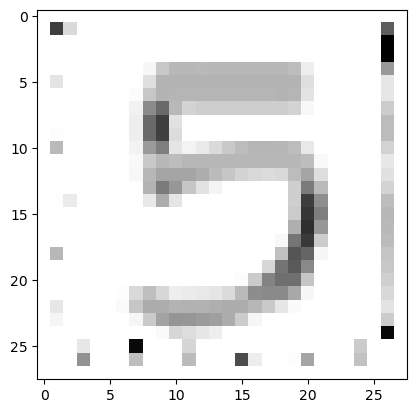

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
The digit is probably a 1


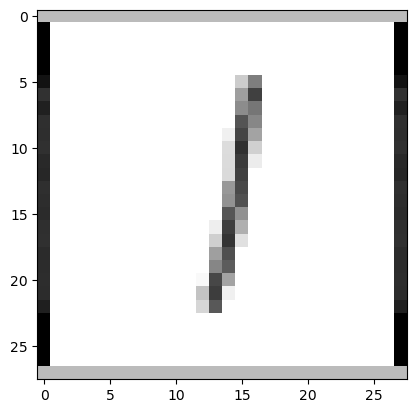

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
The digit is probably a 3


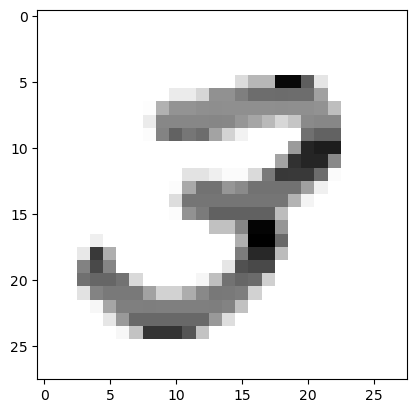

In [90]:

image_number = 2
folder_path = r"C:\Users\muham\Desktop\digit"  # Use the correct folder path

while os.path.isfile(os.path.join(folder_path, f"{image_number}.png")):  # Looking for PNG images
    try:
        img_path = os.path.join(folder_path, f"{image_number}.png")  # Image path with .png extension
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale

        # Invert image for black background (if pixel value > 127)
        if np.mean(img) < 127:  # Check if it's likely a black background
            img = cv2.bitwise_not(img)  # Invert the image

        img = cv2.resize(img, (28, 28))         # Resize image to 28x28 pixels
        img = np.invert(img)                    # Invert pixels (to get black digits on white bg)
        img = tf.keras.utils.normalize(img, axis=1)  # Normalize pixel values to [0, 1]
        img = np.array([img])                   # Add extra dimension for prediction

        prediction = model.predict(img)         # Make prediction
        print(f"The digit is probably a {np.argmax(prediction)}")

        plt.imshow(img[0], cmap=plt.cm.binary)  # Show the image
        plt.show()

    except Exception as e:
        print(f"Error processing image {image_number}: {e}")
    
    image_number += 1  # Increment to move to the next image
